## FischerJordan DA Assignment
**Name:** Palak Verma

## 1. Problem Statement

A shoe company ships 4 lb parcels across India using multiple carriers 
(Delhivery, DTDC, Blue Dart, FedEx, etc.). 

The goal is to:
- Design a **normalized shipment cost model**
- Enable **fair comparison** of shipping costs across carriers
- Identify which charges are base cost vs surcharges
- Find the **worst 10% shipments** by cost and analyze them

## 2. Data Overview

| Field | Value |
|-------|-------|
| Total Records | 214 |
| Unique Shipments | 106 |
| Carriers | 9 |
| Zones | 6 |
| Unique Charge Types | 196 |
| Missing Values | None |

## 3. Charge Classification

To normalize costs fairly, all 196 charge types were grouped into 5 categories:

| Category | Included in Normalized Cost? | Reason |
|----------|------------------------------|--------|
| Base Rate | Yes | Core carrier charge |
| Operational Surcharge | Yes | Unavoidable, applies to all carriers equally |
| Tax & Customs | No | Government imposed, not carrier's pricing |
| Penalty/Correction | No | Shipper's fault, avoidable |
| Optional/Special Service | No | Shipper elected, not carrier's decision |

**Key Finding:** Only 2 out of 106 shipments had a Base Rate entry.
For remaining 104 shipments, Total Cost was used as Normalized Cost.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('FJ_Assignment.csv')

print("Dataset Shape:", df.shape)
print("Unique Shipments:", df['Tracking Number'].nunique())
print("Carriers:", df['Carrier Name'].unique())
print("Missing Values:\n", df.isnull().sum())

Dataset Shape: (214, 11)
Unique Shipments: 106
Carriers: ['Delhivery' 'DTDC' 'Blue Dart' 'FedEx' 'Gati' 'Ekart Logistics' 'DHL'
 'Ecom Express' 'Safe Express']
Missing Values:
 Tracking Number     0
Carrier Name        0
Service Level       0
Zones               0
Weight (lbs)        0
Dimensions (in)     0
Charge Type         0
Charge              0
Pickup Zipcode      0
Dropoff Zipcode     0
Date of Delivery    0
dtype: int64


## 4. Data Cleaning & Classification
- Removed `$` from Charge column
- Removed `lbs` from Weight column  
- Standardized Zones: `"Zone 3"` → `"3"`
- Applied `classify_charge()` function to categorize all 196 charge types

In [2]:
# Classify charge types
def classify_charge(charge_type):
    ct = str(charge_type).strip().lower()
    if ct in ['base rate', 'freight']:
        return 'Base Rate'
    elif 'fuel' in ct or 'delivery area' in ct or 'das' in ct or 'residential' in ct:
        return 'Operational Surcharge'
    elif 'tax' in ct or 'gst' in ct or 'duty' in ct or 'customs' in ct or 'brokerage' in ct:
        return 'Tax & Customs'
    elif 'adjustment' in ct or 'correction' in ct or 'admin' in ct or 'billing' in ct:
        return 'Penalty/Correction'
    elif 'signature' in ct or 'saturday' in ct or 'hazardous' in ct or 'future day' in ct:
        return 'Optional/Special Service'
    else:
        return 'Other Surcharge'

df['Charge_Category'] = df['Charge Type'].apply(classify_charge)

# Clean columns
df['Charge'] = pd.to_numeric(
    df['Charge'].astype(str).str.replace('$', '', regex=False).str.strip(), errors='coerce')
df['Weight (lbs)'] = pd.to_numeric(
    df['Weight (lbs)'].astype(str).str.replace(' lbs', '', regex=False).str.strip(), errors='coerce')
df['Zones'] = df['Zones'].astype(str).str.replace('Zone ', '', regex=False).str.strip()

print("Charge Category Counts:")
print(df['Charge_Category'].value_counts())

Charge Category Counts:
Charge_Category
Optional/Special Service    103
Penalty/Correction           39
Other Surcharge              31
Tax & Customs                20
Operational Surcharge        19
Base Rate                     2
Name: count, dtype: int64


## 5. Normalization Methodology

**Normalized Cost = Base Rate + Operational Surcharge**

For shipments missing Base Rate (104/106), Total Cost was used as fallback.

**Assumption:** Since 98% of shipments lack a Base Rate entry, 
Total Cost and Normalized Cost are nearly identical in this dataset.
This means carrier rankings remain the same with or without normalization.

In [3]:
# Pivot cost by category per shipment
cost_pivot = df.pivot_table(
    index='Tracking Number',
    columns='Charge_Category',
    values='Charge',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Get carrier, zone, weight per shipment
meta = df.groupby('Tracking Number').agg(
    Carrier=('Carrier Name', 'first'),
    Zone=('Zones', 'first'),
    Weight=('Weight (lbs)', 'first')
).reset_index()

# Merge
shipment = meta.merge(cost_pivot, on='Tracking Number', how='left')

# Calculate costs
shipment['Total_Cost'] = shipment[['Base Rate', 'Operational Surcharge',
                                    'Optional/Special Service', 'Tax & Customs',
                                    'Penalty/Correction', 'Other Surcharge']].sum(axis=1)

shipment['Normalized_Cost'] = shipment['Base Rate'] + shipment['Operational Surcharge']
shipment.loc[shipment['Base Rate'] == 0, 'Normalized_Cost'] = shipment['Total_Cost']

shipment['Cost_per_lb'] = (shipment['Normalized_Cost'] / shipment['Weight']).round(2)

print("Shipment Summary (first 10):")
print(shipment[['Tracking Number', 'Carrier', 'Zone', 
                'Weight', 'Total_Cost', 'Normalized_Cost', 'Cost_per_lb']].head(10))

Shipment Summary (first 10):
  Tracking Number          Carrier Zone  Weight  Total_Cost  Normalized_Cost  \
0    0F10987POIUY     Safe Express    2       4        25.0             25.0   
1    0F10987ZXCVB     Ecom Express    2       4       100.0            100.0   
2    0F32109MNBVC        Delhivery    4       5        30.0             30.0   
3    0F32109POIUY  Ekart Logistics    3       4        25.0             25.0   
4    0F32109ZXCVB             DTDC    1       5        30.0             30.0   
5    0F43210MNBVC             Gati    1       4       100.0            100.0   
6    0F54321LKJHG        Blue Dart    5       4        25.5             25.5   
7    0F54321WXYZA             Gati    3       4        25.5             25.5   
8    0F76543LKJHG            FedEx    5       6       105.0            105.0   
9    0F98765MNBVC              DHL    3       4        25.0             25.0   

   Cost_per_lb  
0         6.25  
1        25.00  
2         6.00  
3         6.25  
4    

## 6. Carrier Comparison

In [4]:
carrier_avg = shipment.groupby('Carrier').agg(
    Shipments=('Tracking Number', 'count'),
    Avg_Total_Cost=('Total_Cost', 'mean'),
    Avg_Normalized_Cost=('Normalized_Cost', 'mean'),
    Avg_Cost_per_lb=('Cost_per_lb', 'mean'),
    Total_Spend=('Total_Cost', 'sum')
).round(2).reset_index().sort_values('Avg_Normalized_Cost')

print(carrier_avg)

           Carrier  Shipments  Avg_Total_Cost  Avg_Normalized_Cost  \
5  Ekart Logistics         13           41.02                37.17   
2             DTDC         14           42.20                42.20   
3        Delhivery         13           42.37                42.37   
0        Blue Dart         11           46.70                46.70   
4     Ecom Express         11           48.43                48.43   
7             Gati         12           50.15                50.15   
1              DHL         11           51.05                51.05   
6            FedEx         12           61.98                61.98   
8     Safe Express          9           63.25                63.25   

   Avg_Cost_per_lb  Total_Spend  
5             8.98       533.25  
2            10.03       590.75  
3             9.24       550.75  
0            11.08       513.75  
4            11.64       532.75  
7            12.41       601.75  
1            12.33       561.50  
6            13.50       74

## 7. Charts & Insights

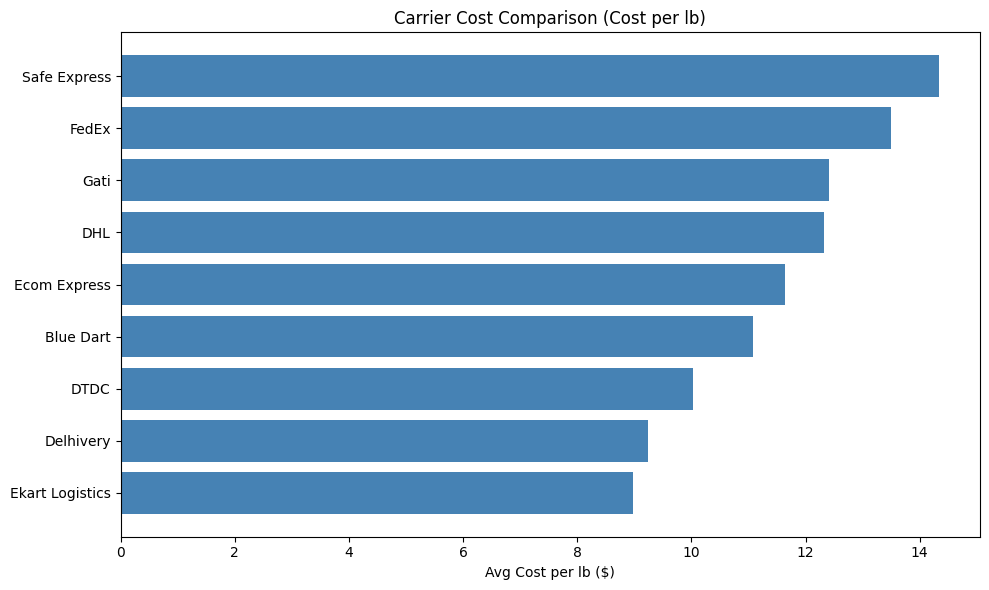

In [5]:
# Chart 1
carrier_sorted = carrier_avg.sort_values('Avg_Cost_per_lb')
plt.figure(figsize=(10, 6))
plt.barh(carrier_sorted['Carrier'], carrier_sorted['Avg_Cost_per_lb'], color='steelblue')
plt.xlabel('Avg Cost per lb ($)')
plt.title('Carrier Cost Comparison (Cost per lb)')
plt.tight_layout()
plt.show()

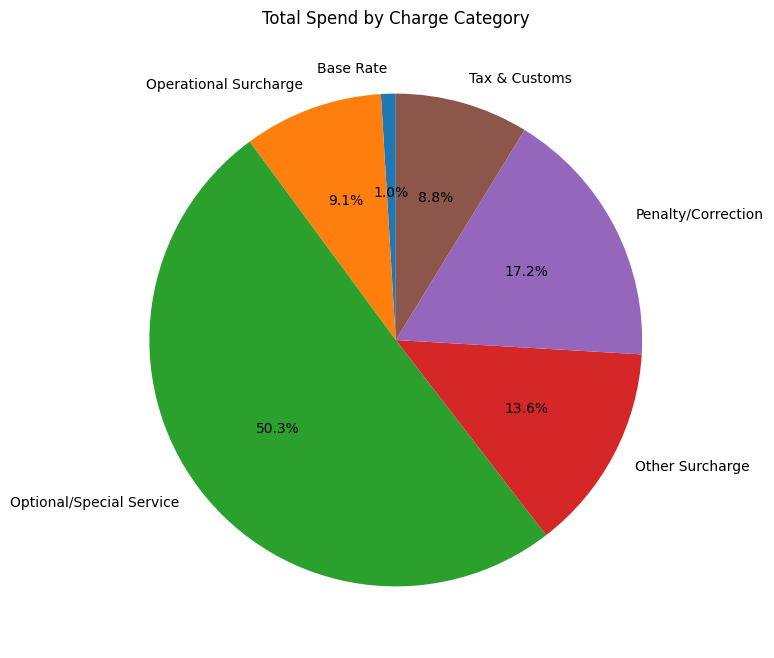

In [6]:
# Chart 2
category_spend = df.groupby('Charge_Category')['Charge'].sum()
plt.figure(figsize=(8, 8))
plt.pie(category_spend.values, labels=category_spend.index, autopct='%1.1f%%', startangle=90)
plt.title('Total Spend by Charge Category')
plt.show()

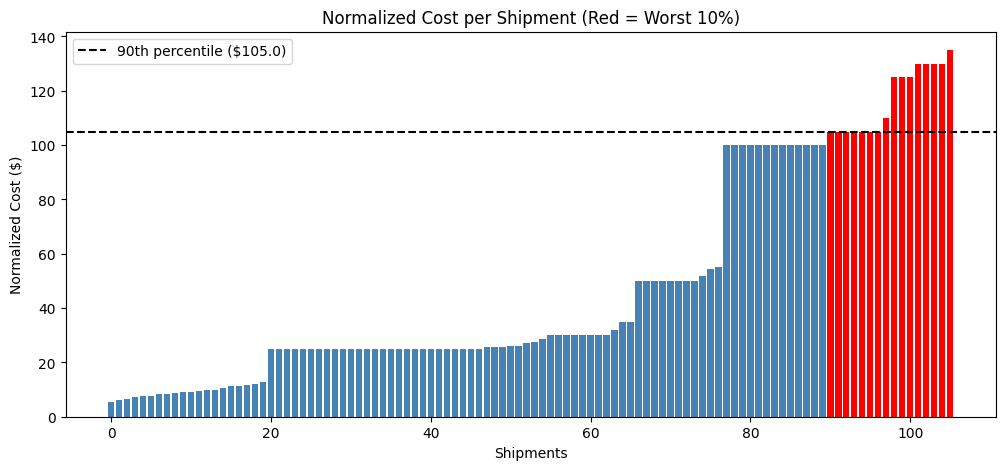

In [7]:
# Chart 3
threshold = shipment['Normalized_Cost'].quantile(0.90)
shipment_sorted = shipment.sort_values('Normalized_Cost').reset_index(drop=True)
colors = ['red' if x >= threshold else 'steelblue' for x in shipment_sorted['Normalized_Cost']]
plt.figure(figsize=(12, 5))
plt.bar(range(len(shipment_sorted)), shipment_sorted['Normalized_Cost'], color=colors)
plt.axhline(y=threshold, color='black', linestyle='--', label=f'90th percentile (${threshold})')
plt.xlabel('Shipments')
plt.ylabel('Normalized Cost ($)')
plt.title('Normalized Cost per Shipment (Red = Worst 10%)')
plt.legend()
plt.show()

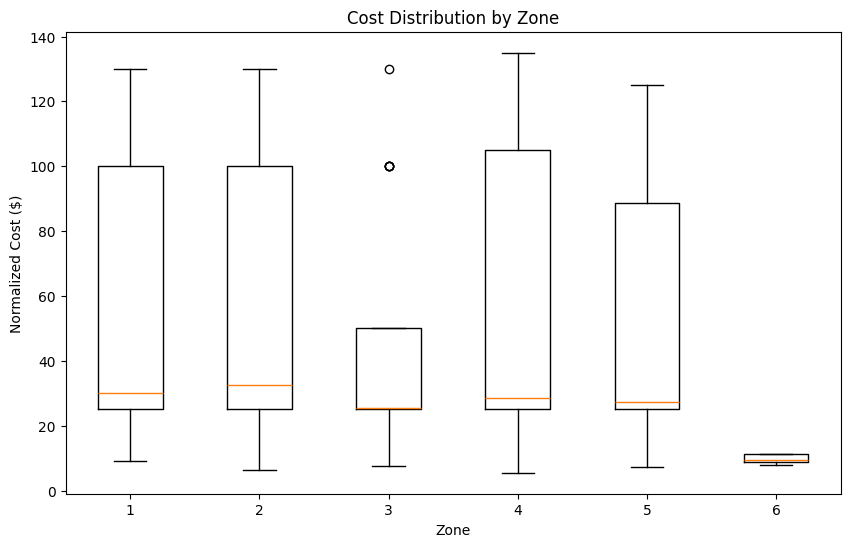

In [8]:
# Chart 4
zone_groups = [shipment[shipment['Zone'] == str(z)]['Normalized_Cost'].dropna().values
               for z in sorted(shipment['Zone'].unique())]
plt.figure(figsize=(10, 6))
plt.boxplot(zone_groups, tick_labels=sorted(shipment['Zone'].unique()))
plt.xlabel('Zone')
plt.ylabel('Normalized Cost ($)')
plt.title('Cost Distribution by Zone')
plt.show()

## 8. Worst 10% Analysis

In [9]:
worst = shipment[shipment['Normalized_Cost'] >= threshold].copy()
print(f"Threshold: ${threshold:.2f}")
print(f"Worst shipments: {len(worst)}")
print(f"Their spend: ${worst['Total_Cost'].sum():.2f}")
print(f"% of total spend: {worst['Total_Cost'].sum() / shipment['Total_Cost'].sum() * 100:.1f}%")
print("\nBy Carrier:\n", worst['Carrier'].value_counts())
print("\nBy Zone:\n", worst['Zone'].value_counts())

Threshold: $105.00
Worst shipments: 16
Their spend: $1875.00
% of total spend: 36.1%

By Carrier:
 Carrier
FedEx           3
Delhivery       3
Gati            2
Blue Dart       2
Ecom Express    2
Safe Express    2
DHL             1
DTDC            1
Name: count, dtype: int64

By Zone:
 Zone
4    6
2    4
1    3
5    2
3    1
Name: count, dtype: int64


## 9. Key Findings & Recommendations

1. **Ekart Logistics** is cheapest at 8.98/lb, **Safe Express** is costliest at 14.34/lb
2. **50.3% of spend** is on Optional/Special Services — review necessity of each
3. **17.2% of spend** is Penalties/Corrections — completely avoidable waste
4. **Worst 10% shipments** (16 out of 106) = 36.1% of total spend ($1,875)
5. **Zone 4** has highest cost spread — riskiest zone for budgeting

### Recommendations
- Replace Safe Express & FedEx with Ekart Logistics where possible
- Audit all Adult Signature & Special Service charges
- Investigate and fix address correction issues to reduce penalties
- Negotiate special rates for Zone 4 shipments


## 10. Assumptions & Limitations

- 104/106 shipments had no Base Rate — Total Cost used as proxy
- Normalization did not change carrier rankings in this dataset
- Weight inconsistencies (`4 lbs` vs `4`) were cleaned programmatically
- Zone inconsistencies (`Zone 3` vs `3`) were standardized
- AI tools were used for guidance in structuring the analysis